# INSTALLS

In [3]:
# ==========================================================
# CELL 1: INSTALLS (COLAB)
# ==========================================================
!pip -q install earthengine-api openpyxl tensorflow

In [4]:
# ==========================================================
# CELL 2: IMPORTS
# ==========================================================
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Input, Conv2D, MaxPooling2D,
    GlobalAveragePooling2D, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [5]:
# ==========================================================
# CELL 3: FILE PATHS
# Load input files from Google Drive
# ==========================================================
from google.colab import drive
drive.mount('/content/drive')

import os

base = "/content/drive/MyDrive/CSCE nightlights_project"

PATH_TAX = os.path.join(base, "Sales_Tax_Allocation_TX_City.xlsx")
PATH_RAD = os.path.join(base, "Texas_City_Night_Lights_Mean_Sum.csv")
PATH_POP = os.path.join(base, "Population Texas Cities.xlsx")

assert os.path.exists(PATH_TAX), f"Missing file: {PATH_TAX}"
assert os.path.exists(PATH_RAD), f"Missing file: {PATH_RAD}"
assert os.path.exists(PATH_POP), f"Missing file: {PATH_POP}"

print("Tax file found:", PATH_TAX)
print("Radiance file found:", PATH_RAD)
print("Population file found:", PATH_POP)

Mounted at /content/drive
Tax file found: /content/drive/MyDrive/CSCE nightlights_project/Sales_Tax_Allocation_TX_City.xlsx
Radiance file found: /content/drive/MyDrive/CSCE nightlights_project/Texas_City_Night_Lights_Mean_Sum.csv
Population file found: /content/drive/MyDrive/CSCE nightlights_project/Population Texas Cities.xlsx


In [6]:
# ==========================================================
# CELL 4: HELPERS
# ==========================================================
def normalize_city_name(x):
    """
    Standardize city names for merging.
    """
    x = str(x).strip().upper()
    x = re.sub(r"\.", "", x)
    x = re.sub(r"\s+", " ", x)
    return x

def safe_log1p(x):
    return np.log1p(np.clip(x, a_min=0, a_max=None))

def evaluate_regression(y_true, y_pred, model_name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    out = {
        "model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }
    return out

def print_eval(d):
    print(f"{d['model']}:")
    print(f"  RMSE = {d['RMSE']:.4f}")
    print(f"  MAE  = {d['MAE']:.4f}")
    print(f"  R2   = {d['R2']:.4f}")

# DATA LOADING

In [7]:
# ==========================================================
# CELL 5A: LOAD TAX DATA
# ==========================================================
tax = pd.read_excel(PATH_TAX, sheet_name="Sales_Tax_Allocation_TX_City")
tax.columns = [c.strip() for c in tax.columns]

print("Tax shape:", tax.shape)
print("Tax columns:", tax.columns.tolist())

# Rename for convenience
tax = tax.rename(columns={
    "City": "City",
    "Net Payment This Period": "net_payment",
    "Report Month": "report_month",
    "Report Year": "report_year"
})

# Basic cleaning
tax["City_std"] = tax["City"].astype(str).map(normalize_city_name)
tax["net_payment"] = pd.to_numeric(tax["net_payment"], errors="coerce")
tax["report_month"] = pd.to_numeric(tax["report_month"], errors="coerce")
tax["report_year"] = pd.to_numeric(tax["report_year"], errors="coerce")

tax = tax.dropna(subset=["City_std", "net_payment", "report_month", "report_year"]).copy()
tax["report_month"] = tax["report_month"].astype(int)
tax["report_year"] = tax["report_year"].astype(int)

tax["month"] = pd.to_datetime(
    dict(year=tax["report_year"], month=tax["report_month"], day=1),
    errors="coerce"
)

tax = tax.dropna(subset=["month"]).copy()
tax["log_tax"] = safe_log1p(tax["net_payment"])

print("Tax date range:", tax["month"].min(), "to", tax["month"].max())
print("Tax cities:", tax["City_std"].nunique())
print(tax.head())

Tax shape: (139668, 5)
Tax columns: ['City', 'Net Payment This Period', 'Payment to Date', 'Report Month', 'Report Year']
Tax date range: 2016-01-01 00:00:00 to 2025-12-01 00:00:00
Tax cities: 1181
   City  net_payment  Payment to Date  report_month  report_year City_std  \
0  Ames          0.0         17475.27             6         2022     AMES   
1  Ames          0.0         17475.27             7         2022     AMES   
2  Ames          0.0         17475.27             8         2022     AMES   
3  Ames          0.0         17475.27             9         2022     AMES   
4  Ames          0.0         17475.27            10         2022     AMES   

       month  log_tax  
0 2022-06-01      0.0  
1 2022-07-01      0.0  
2 2022-08-01      0.0  
3 2022-09-01      0.0  
4 2022-10-01      0.0  


In [8]:
# ==========================================================
# CELL 5B: LOAD RADIANCE DATA
# ==========================================================
rad = pd.read_csv(PATH_RAD)
rad.columns = [c.strip() for c in rad.columns]

print("Radiance shape:", rad.shape)
print("Radiance columns:", rad.columns.tolist())

rad["City_std"] = rad["City"].astype(str).map(normalize_city_name)
rad["month"] = pd.to_datetime(rad["date"].astype(str) + "-01", errors="coerce")

for col in ["avg_rad_mean", "avg_rad_sum"]:
    rad[col] = pd.to_numeric(rad[col], errors="coerce")

# Keep useful columns
keep_cols = ["GEOID", "City", "City_std", "month", "avg_rad_mean", "avg_rad_sum"]
rad = rad[keep_cols].dropna(subset=["City_std", "month", "avg_rad_mean", "avg_rad_sum"]).copy()

# Some GEOIDs may load as numeric. Make them clean strings.
rad["GEOID"] = rad["GEOID"].astype(str).str.replace(r"\.0$", "", regex=True)

# Log transforms
rad["log_avg_rad_mean"] = safe_log1p(rad["avg_rad_mean"])
rad["log_avg_rad_sum"]  = safe_log1p(rad["avg_rad_sum"])

print("Radiance date range:", rad["month"].min(), "to", rad["month"].max())
print("Radiance cities:", rad["City_std"].nunique())
print(rad.head())

Radiance shape: (223560, 6)
Radiance columns: ['system:index', 'GEOID', 'City', 'avg_rad_mean', 'avg_rad_sum', 'date']
Radiance date range: 2016-01-01 00:00:00 to 2025-12-01 00:00:00
Radiance cities: 1840
     GEOID    City City_std      month  avg_rad_mean  avg_rad_sum  \
0  4800100  Abbott   ABBOTT 2016-01-01      3.585053    44.637428   
1  4800100  Abbott   ABBOTT 2016-02-01      3.834059    47.737797   
2  4800100  Abbott   ABBOTT 2016-03-01      4.090054    50.925179   
3  4800100  Abbott   ABBOTT 2016-04-01      3.708708    46.177047   
4  4800100  Abbott   ABBOTT 2016-05-01      4.101157    51.063431   

   log_avg_rad_mean  log_avg_rad_sum  
0          1.522802         3.820728  
1          1.575687         3.886455  
2          1.627288         3.949804  
3          1.549413         3.853907  
4          1.629467         3.952463  


Population shape: (1218, 11)
Population columns: ['City', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']
Population year range: 2016 to 2025
Population cities: 1215
                 City     City_clean       City_std  year  population
0         Abbott city         Abbott         ABBOTT  2016         343
1      Abernathy city      Abernathy      ABERNATHY  2016        2853
2        Abilene city        Abilene        ABILENE  2016      122528
3        Ackerly city        Ackerly        ACKERLY  2016         249
4        Addison town        Addison        ADDISON  2016       15095
5         Adrian city         Adrian         ADRIAN  2016         139
6     Agua Dulce city     Agua Dulce     AGUA DULCE  2016         745
7          Alamo city          Alamo          ALAMO  2016       18920
8  Alamo Heights city  Alamo Heights  ALAMO HEIGHTS  2016        7439
9           Alba town           Alba           ALBA  2016         469


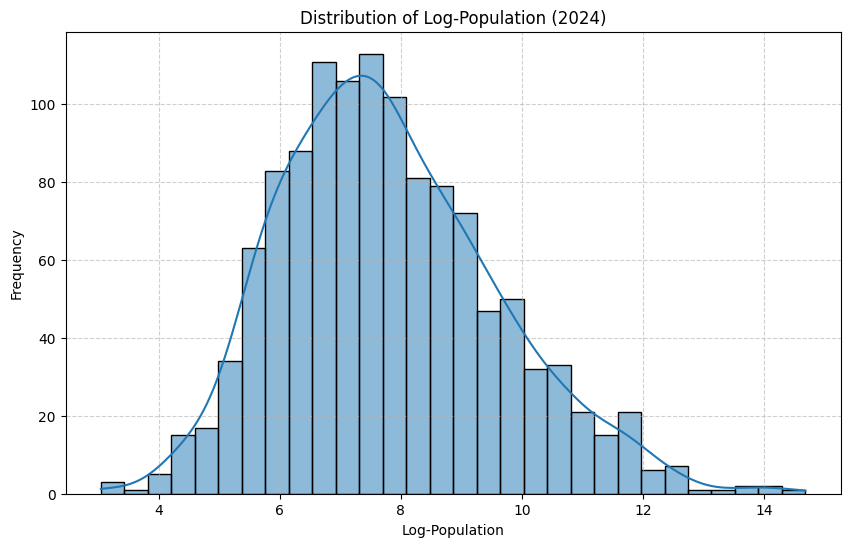

,City,City_clean,City_std,year,population,log_population
9744,Abbott city,Abbott,ABBOTT,2024,370,5.916202
9745,Abernathy city,Abernathy,ABERNATHY,2024,2838,7.951207
9746,Abilene city,Abilene,ABILENE,2024,130501,11.779144
9747,Ackerly city,Ackerly,ACKERLY,2024,261,5.568345
9748,Addison town,Addison,ADDISON,2024,17257,9.756031


In [9]:
# ==========================================================
# CELL 5C: LOAD POPULATION DATA
# ==========================================================
pop = pd.read_excel(PATH_POP)
pop.columns = [str(c).strip() for c in pop.columns]

print("Population shape:", pop.shape)
print("Population columns:", pop.columns.tolist())

# Rename city column if needed
pop = pop.rename(columns={pop.columns[0]: "City"})

# Remove trailing city/town/village/CDP from names before standardizing
pop["City_clean"] = (
    pop["City"]
    .astype(str)
    .str.replace(r"\s+(city|town|village|CDP)$", "", regex=True, case=False)
    .str.strip()
)

pop["City_std"] = pop["City_clean"].map(normalize_city_name)

# Convert wide year columns into long format
year_cols = [c for c in pop.columns if str(c).strip().isdigit()]

pop_long = pop.melt(
    id_vars=["City", "City_clean", "City_std"],
    value_vars=year_cols,
    var_name="year",
    value_name="population"
)

pop_long["year"] = pop_long["year"].astype(int)

# Clean commas, spaces, and convert to numeric
pop_long["population"] = (
    pop_long["population"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(" ", "", regex=False)
)

pop_long["population"] = pd.to_numeric(pop_long["population"], errors="coerce")

pop_long = pop_long.dropna(subset=["City_std", "year", "population"]).copy()
pop_long["population"] = pop_long["population"].astype(int)

print("Population year range:", pop_long["year"].min(), "to", pop_long["year"].max())
print("Population cities:", pop_long["City_std"].nunique())
print(pop_long.head(10))

#Histogram
pop_long["log_population"] = np.log1p(pop_long["population"])

pop_2024 = pop_long[pop_long["year"] == 2024]

plt.figure(figsize=(10, 6))
sns.histplot(pop_2024["log_population"], kde=True, bins=30)
plt.title("Distribution of Log-Population (2024)")
plt.xlabel("Log-Population")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

display(pop_2024.head())

### Population Distribution for 2024

In [10]:
# ==========================================================
# CELL 6: MERGE TO MASTER PANEL
# IMPORTANT: SAME CITY-MONTHS FOR EVERY MODEL
# ==========================================================
panel = tax.merge(
    rad[[
        "GEOID", "City_std", "month",
        "avg_rad_mean", "avg_rad_sum",
        "log_avg_rad_mean", "log_avg_rad_sum"
    ]],
    on=["City_std", "month"],
    how="inner"
).copy()

# Add year for population merge
panel["year"] = panel["month"].dt.year

panel = panel.merge(
    pop_long[["City_std", "year", "population"]],
    on=["City_std", "year"],
    how="left"
)

panel = panel.sort_values(["City_std", "month"]).reset_index(drop=True)

print("Merged panel shape:", panel.shape)
print("Matched cities:", panel["City_std"].nunique())
print("Date range:", panel["month"].min(), "to", panel["month"].max())
print("Missing population rows:", panel["population"].isna().sum())
print("Cities missing population:", panel.loc[panel["population"].isna(), "City_std"].nunique())

# Safety checks
assert panel.shape[0] > 0, "Merged panel is empty."
assert panel["month"].min() >= pd.Timestamp("2016-01-01")
assert panel["month"].max() <= pd.Timestamp("2025-12-01")

# Optional lags for a later extension
panel["lag1_log_tax"] = panel.groupby("City_std")["log_tax"].shift(1)
panel["lag3_log_tax"] = panel.groupby("City_std")["log_tax"].shift(3)

panel.head()

Merged panel shape: (138213, 15)
Matched cities: 1147
Date range: 2016-01-01 00:00:00 to 2025-12-01 00:00:00
Missing population rows: 646
Cities missing population: 9


,City,net_payment,Payment to Date,report_month,report_year,City_std,month,log_tax,GEOID,avg_rad_mean,avg_rad_sum,log_avg_rad_mean,log_avg_rad_sum,year,population,lag1_log_tax,lag3_log_tax
0,Abbott,4523.83,4523.83,1,2016,ABBOTT,2016-01-01,8.417335,4800100,3.585053,44.637428,1.522802,3.820728,2016,343.0,NaN,NaN
1,Abbott,10108.83,14632.66,2,2016,ABBOTT,2016-02-01,9.221263,4800100,3.834059,47.737797,1.575687,3.886455,2016,343.0,8.417335,NaN
2,Abbott,4039.34,18672.00,3,2016,ABBOTT,2016-03-01,8.304084,4800100,4.090054,50.925179,1.627288,3.949804,2016,343.0,9.221263,NaN
3,Abbott,6348.30,25020.30,4,2016,ABBOTT,2016-04-01,8.756100,4800100,3.708708,46.177047,1.549413,3.853907,2016,343.0,8.304084,8.417335
4,Abbott,10448.48,35468.78,5,2016,ABBOTT,2016-05-01,9.254307,4800100,4.101157,51.063431,1.629467,3.952463,2016,343.0,8.756100,9.221263


# DESCRIPTIVES

Rows: 138213
Cities: 1147
Months: 120

Descriptive Statistics:


,N,Mean,SD,Min,25%,Median,75%,Max
Net Payment,138213.0,513216.65,2699673.42,0.0,8365.35,35501.04,205783.76,94343882.03
Log Tax,138213.0,10.62,2.30,0.0,9.03,10.48,12.23,18.36
Radiance Mean,138213.0,10.70,11.02,0.0,3.55,7.27,13.52,272.00
Radiance Sum,138213.0,2642.66,16069.34,0.0,70.01,239.36,1052.30,553288.98
Log Radiance Mean,138213.0,2.13,0.80,0.0,1.51,2.11,2.68,5.61
Log Radiance Sum,138213.0,5.67,1.93,0.0,4.26,5.48,6.96,13.22
Population,137567.0,18770.66,104820.03,2.0,736.00,2088.00,7668.50,2433342.00



Correlation Matrix:


,log_tax,log_avg_rad_mean,log_avg_rad_sum,avg_rad_mean,avg_rad_sum,population
log_tax,1.00,0.74,0.90,0.60,0.33,0.36
log_avg_rad_mean,0.74,1.00,0.76,0.88,0.23,0.23
log_avg_rad_sum,0.90,0.76,1.00,0.64,0.38,0.40
avg_rad_mean,0.60,0.88,0.64,1.00,0.27,0.26
avg_rad_sum,0.33,0.23,0.38,0.27,1.00,0.97
population,0.36,0.23,0.40,0.26,0.97,1.00



Saved tables to Drive:
/content/drive/MyDrive/CSCE nightlights_project/panel_counts.csv
/content/drive/MyDrive/CSCE nightlights_project/descriptive_statistics_pretty.csv
/content/drive/MyDrive/CSCE nightlights_project/correlation_matrix.csv


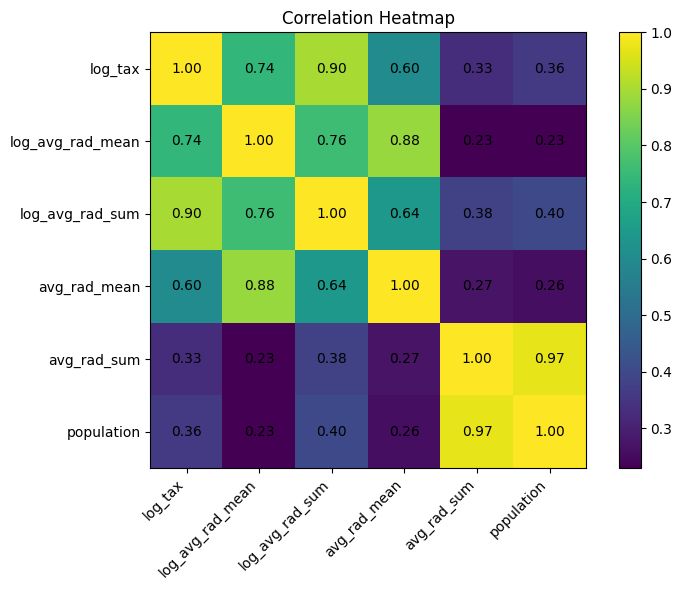


Saved: /content/drive/MyDrive/CSCE nightlights_project/correlation_heatmap2.png


In [11]:
# ==========================================================
# CELL 7: DESCRIPTIVES + EXPORTS
# ==========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Output folder (Drive)
# ----------------------------
base = "/content/drive/MyDrive/CSCE nightlights_project"
os.makedirs(base, exist_ok=True)

# ----------------------------
# Basic counts
# ----------------------------
n_rows = len(panel)
n_cities = panel["City_std"].nunique()
n_months = panel["month"].nunique()

print("Rows:", n_rows)
print("Cities:", n_cities)
print("Months:", n_months)
print()

counts_df = pd.DataFrame({
    "Metric": ["Rows", "Cities", "Months"],
    "Value": [n_rows, n_cities, n_months]
})

# ----------------------------
# Descriptive statistics (clean + pretty)
# ----------------------------
desc_cols = [
    "net_payment", "log_tax",
    "avg_rad_mean", "avg_rad_sum",
    "log_avg_rad_mean", "log_avg_rad_sum","population"
]

pretty_names = {
    "net_payment": "Net Payment",
    "log_tax": "Log Tax",
    "avg_rad_mean": "Radiance Mean",
    "avg_rad_sum": "Radiance Sum",
    "log_avg_rad_mean": "Log Radiance Mean",
    "log_avg_rad_sum": "Log Radiance Sum",
    "population": "Population"
}

desc_stats = panel[desc_cols].describe().T

# Keep important columns only
desc_stats = desc_stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

# Rename
desc_stats.index = [pretty_names.get(idx, idx) for idx in desc_stats.index]
desc_stats.columns = ["N", "Mean", "SD", "Min", "25%", "Median", "75%", "Max"]

# Round to 2 decimals
desc_stats = desc_stats.round(2)

print("Descriptive Statistics:")
display(desc_stats)
print()

# ----------------------------
# Correlation matrix
# ----------------------------
corr_cols = [
    "log_tax",
    "log_avg_rad_mean",
    "log_avg_rad_sum",
    "avg_rad_mean",
    "avg_rad_sum",
    "population"
]

corr_matrix = panel[corr_cols].corr().round(2)

print("Correlation Matrix:")
display(corr_matrix)

# ----------------------------
# Export tables
# ----------------------------
counts_df.to_csv(f"{base}/panel_counts.csv", index=False)
desc_stats.to_csv(f"{base}/descriptive_statistics_pretty.csv", float_format="%.2f")
#corr_matrix.to_csv(f"{base}/correlation_matrix.csv", float_format="%.2f")

print("\nSaved tables to Drive:")
print(f"{base}/panel_counts.csv")
print(f"{base}/descriptive_statistics_pretty.csv")
print(f"{base}/correlation_matrix.csv")

# ----------------------------
# Correlation heatmap (PPT-ready)
# ----------------------------
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(corr_matrix.values)

# Labels
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

# Annotate values
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center")

ax.set_title("Correlation Heatmap")
fig.colorbar(im, ax=ax)

plt.tight_layout()

plt.savefig(f"{base}/correlation_heatmap2.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved: {base}/correlation_heatmap2.png")

In [12]:
# ==========================================================
# CELL 8: TRAIN / VALID / TEST SPLIT
# Clean time split:
# Train = 2016-01 to 2023-12
# Valid = 2024-01 to 2024-12
# Test  = 2025-01 to 2025-12
# ==========================================================
train_end = pd.Timestamp("2023-12-01")
valid_end = pd.Timestamp("2024-12-01")

train_df = panel[panel["month"] <= train_end].copy()
valid_df = panel[(panel["month"] > train_end) & (panel["month"] <= valid_end)].copy()
test_df  = panel[panel["month"] > valid_end].copy()

print("Train rows:", train_df.shape)
print("Valid rows:", valid_df.shape)
print("Test rows :", test_df.shape)

assert len(train_df) > 0 and len(valid_df) > 0 and len(test_df) > 0, "Empty split detected."

Train rows: (110382, 17)
Valid rows: (13908, 17)
Test rows : (13923, 17)


In [13]:
# ==========================================================
# CELL 9: RADIANCE-ONLY FEATURES
# MAIN COMPARISON
# ==========================================================
target = "log_tax"

rad_features = [
    "log_avg_rad_mean",
    "log_avg_rad_sum"
]

X_train = train_df[rad_features].copy()
y_train = train_df[target].copy()

X_valid = valid_df[rad_features].copy()
y_valid = valid_df[target].copy()

X_test = test_df[rad_features].copy()
y_test = test_df[target].copy()

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s  = scaler.transform(X_test)

print("Radiance feature shapes:")
print(X_train_s.shape, X_valid_s.shape, X_test_s.shape)

Radiance feature shapes:
(110382, 2) (13908, 2) (13923, 2)


# MODELS

## 1. Linear Regression

In [14]:
# ==========================================================
# CELL 10A: CONSISTENT WHOLE-SAMPLE LINEAR REGRESSION
# Train once on the full training sample
# ==========================================================

from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

features = ["log_avg_rad_mean","log_avg_rad_sum"]
target = "log_tax"

# Make sure train/test contain the same variables
X_train = train_df[features].copy()
y_train = train_df[target].copy()

X_test = test_df[features].copy()
y_test = test_df[target].copy()

# Train pooled model
lr_pooled = LinearRegression()
lr_pooled.fit(X_train, y_train)

# Predict for full test sample
y_pred_test_pooled = lr_pooled.predict(X_test)

pooled_eval = evaluate_regression(
    y_test,
    y_pred_test_pooled,
    "Linear Regression - Pooled Model, Full Test Sample"
)

print_eval(pooled_eval)

coef_df = pd.DataFrame({
    "feature": features,
    "coef": lr_pooled.coef_
}).sort_values("coef", key=np.abs, ascending=False)

print()
display(coef_df)

Linear Regression - Pooled Model, Full Test Sample:
  RMSE = 0.9893
  MAE  = 0.6603
  R2   = 0.8089



,feature,coef
1,log_avg_rad_sum,0.979031
0,log_avg_rad_mean,0.320516


In [15]:
# ==========================================================
# CELL 10B: CREATE POPULATION GROUPS
# Based on average population per city
# ==========================================================

avg_population_per_city = (
    panel.groupby("City_std")["population"]
    .mean()
    .dropna()
    .reset_index(name="avg_population")
)

avg_population_per_city["population_group"] = pd.qcut(
    avg_population_per_city["avg_population"],
    q=5,
    labels=[f"PopGroup_{i+1}" for i in range(5)],
    duplicates="drop"
)

# Add population groups to test data only for evaluation
test_df_grouped = test_df.merge(
    avg_population_per_city[["City_std", "avg_population", "population_group"]],
    on="City_std",
    how="left"
)

test_df_grouped = test_df_grouped.dropna(subset=["population_group"]).reset_index(drop=True)

print("Grouped test shape:", test_df_grouped.shape)
print("Number of groups:", test_df_grouped["population_group"].nunique())

display(
    test_df_grouped[["City_std", "month", "population", "avg_population", "population_group"]].head()
)

Grouped test shape: (13839, 19)
Number of groups: 5


,City_std,month,population,avg_population,population_group
0,ABBOTT,2025-01-01,373.0,356.6,PopGroup_1
1,ABBOTT,2025-02-01,373.0,356.6,PopGroup_1
2,ABBOTT,2025-03-01,373.0,356.6,PopGroup_1
3,ABBOTT,2025-04-01,373.0,356.6,PopGroup_1
4,ABBOTT,2025-05-01,373.0,356.6,PopGroup_1


In [16]:
# ==========================================================
# CELL 10C: EVALUATE SAME POOLED MODEL BY POPULATION GROUP
# No separate re-training inside groups
# ==========================================================

group_results = []

for group_name in sorted(test_df_grouped["population_group"].dropna().unique()):

    test_g = test_df_grouped[test_df_grouped["population_group"] == group_name].copy()

    X_test_g = test_g[features]
    y_test_g = test_g[target]

    y_pred_g = lr_pooled.predict(X_test_g)

    eval_g = evaluate_regression(
        y_test_g,
        y_pred_g,
        f"Pooled Linear Regression on {group_name}"
    )

  #  eval_g["population_group"] = group_name
   # eval_g["test_obs"] = len(test_g)
    eval_g["cities"] = test_g["City_std"].nunique()
    eval_g["avg_population_min"] = test_g["avg_population"].min()
    eval_g["avg_population_max"] = test_g["avg_population"].max()

    group_results.append(eval_g)

results_by_population_consistent = pd.DataFrame(group_results)

# Add full-sample result for comparison
pooled_eval_row = pooled_eval.copy()
# pooled_eval_row["population_group"] = "Full sample"
# pooled_eval_row["test_obs"] = len(test_df)
pooled_eval_row["cities"] = test_df["City_std"].nunique()
pooled_eval_row["avg_population_min"] = test_df["population"].min()
pooled_eval_row["avg_population_max"] = test_df["population"].max()

results_consistent = pd.concat(
    [pd.DataFrame([pooled_eval_row]), results_by_population_consistent],
    ignore_index=True
)

display(results_consistent)

results_consistent.to_csv(
    f"{base}/pooled_lr_performance_by_group.csv",
    index=False
)

print(f"Saved: {base}/pooled_lr_performance_by_group.csv")

,model,RMSE,MAE,R2,cities,avg_population_min,avg_population_max
0,"Linear Regression - Pooled Model, Full Test Sa...",0.989315,0.660317,0.808898,1146,19.00,2433342.0
1,Pooled Linear Regression on PopGroup_1,1.174773,0.794057,0.178068,228,3.75,555.0
2,Pooled Linear Regression on PopGroup_2,0.936725,0.697104,0.051646,227,556.30,1401.3
3,Pooled Linear Regression on PopGroup_3,0.857551,0.666828,0.131855,228,1405.70,3150.6
4,Pooled Linear Regression on PopGroup_4,1.034635,0.637548,0.084520,228,3153.70,10559.0
5,Pooled Linear Regression on PopGroup_5,0.923359,0.509348,0.372301,228,10570.30,2328354.5


Saved: /content/drive/MyDrive/CSCE nightlights_project/pooled_lr_performance_by_group.csv


In [17]:
# ==========================================================
# CELL 10D: WITHIN-CITY DEMEANED ROBUSTNESS CHECK
# Does radiance predict month-to-month deviations within cities?
# ==========================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

within_panel = panel.copy()

within_features_raw = ["log_avg_rad_mean", "log_avg_rad_sum"]
within_target_raw = "log_tax"
city_col = "City_std"

# Demean outcome and predictors within each city
for col in [within_target_raw] + within_features_raw:
    within_panel[col + "_within"] = (
        within_panel[col] -
        within_panel.groupby(city_col)[col].transform("mean")
    )

within_features = [col + "_within" for col in within_features_raw]
within_target = within_target_raw + "_within"

# Use the same time split as the main analysis
within_train_df = within_panel[within_panel["month"] <= train_end].copy()
within_valid_df = within_panel[
    (within_panel["month"] > train_end) &
    (within_panel["month"] <= valid_end)
].copy()
within_test_df = within_panel[within_panel["month"] > valid_end].copy()

X_train_within = within_train_df[within_features]
y_train_within = within_train_df[within_target]

X_test_within = within_test_df[within_features]
y_test_within = within_test_df[within_target]

# Train within-city linear model
lr_within = LinearRegression()
lr_within.fit(X_train_within, y_train_within)

y_pred_within = lr_within.predict(X_test_within)

within_eval = evaluate_regression(
    y_test_within,
    y_pred_within,
    "Within-City Demeaned Linear Regression"
)

print_eval(within_eval)

within_coef_df = pd.DataFrame({
    "feature": within_features,
    "coef": lr_within.coef_
}).sort_values("coef", key=np.abs, ascending=False)

display(within_coef_df)

# Save robustness result
within_results_df = pd.DataFrame([within_eval])
within_results_df.to_csv(
    f"{base}/within_city_demeaned_lr_results.csv",
    index=False
)

print(f"Saved: {base}/within_city_demeaned_lr_results.csv")

Within-City Demeaned Linear Regression:
  RMSE = 0.6273
  MAE  = 0.4244
  R2   = -0.5274


,feature,coef
0,log_avg_rad_mean_within,0.450383
1,log_avg_rad_sum_within,-0.030850


Saved: /content/drive/MyDrive/CSCE nightlights_project/within_city_demeaned_lr_results.csv


In [18]:
# ==========================================================
# CELL 10E: TWO-WAY FIXED-EFFECTS ROBUSTNESS CHECK
# City fixed effects + month-of-year fixed effects
# Keeps only test cities observed in training
# ==========================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

fe_panel = panel.copy()

features_fe = ["log_avg_rad_mean", "log_avg_rad_sum"]
target_fe = "log_tax"
city_col = "City_std"

# Make sure month is datetime
fe_panel["month"] = pd.to_datetime(fe_panel["month"])

# Month-of-year fixed effects: 1 to 12
# This controls for recurring seasonality and can be used for 2025 prediction
fe_panel["month_of_year_fe"] = fe_panel["month"].dt.month.astype(str)

# Use same time split as main analysis
fe_train_df = fe_panel[fe_panel["month"] <= train_end].copy()
fe_test_df = fe_panel[fe_panel["month"] > valid_end].copy()

# Keep required columns only
cols_needed = [target_fe, city_col, "month_of_year_fe"] + features_fe
fe_train_df = fe_train_df[cols_needed].dropna()
fe_test_df = fe_test_df[cols_needed].dropna()

# Fixed effects can only predict cities seen in training
train_cities = set(fe_train_df[city_col].unique())

n_test_before = len(fe_test_df)
fe_test_df = fe_test_df[fe_test_df[city_col].isin(train_cities)].copy()
n_test_after = len(fe_test_df)

print(f"Test observations before filtering: {n_test_before:,}")
print(f"Test observations after filtering to train-seen cities: {n_test_after:,}")
print(f"Dropped test observations: {n_test_before - n_test_after:,}")

# Two-way fixed-effects model:
# city FE + month-of-year FE
fe_formula = (
    f"{target_fe} ~ log_avg_rad_mean + log_avg_rad_sum "
    f"+ C({city_col}) + C(month_of_year_fe)"
)

fe_model = smf.ols(formula=fe_formula, data=fe_train_df).fit()

# Predict on filtered test set
y_test_fe = fe_test_df[target_fe]
y_pred_fe = fe_model.predict(fe_test_df)

fe_eval = {
    "model": "Linear Regression - City FE + Month-of-Year FE",
    "RMSE": np.sqrt(mean_squared_error(y_test_fe, y_pred_fe)),
    "MAE": mean_absolute_error(y_test_fe, y_pred_fe),
    "R2": r2_score(y_test_fe, y_pred_fe)
}

print(fe_eval)

# Display only radiance coefficients
fe_coef_df = pd.DataFrame({
    "feature": features_fe,
    "coef": fe_model.params[features_fe],
    "p_value": fe_model.pvalues[features_fe]
}).reset_index(drop=True)

display(fe_coef_df)

# Save robustness result
fe_results_df = pd.DataFrame([fe_eval])
fe_results_df.to_csv(
    f"{base}/city_fe_monthofyear_fe_lr_results.csv",
    index=False
)

print(f"Saved: {base}/city_fe_monthofyear_fe_lr_results.csv")

Test observations before filtering: 13,923
Test observations after filtering to train-seen cities: 13,896
Dropped test observations: 27
{'model': 'Linear Regression - City FE + Month-of-Year FE', 'RMSE': np.float64(0.6604965989360623), 'MAE': 0.4320351273480044, 'R2': 0.9145666763974752}


,feature,coef,p_value
0,log_avg_rad_mean,0.512292,0.000000e+00
1,log_avg_rad_sum,-0.036657,2.200904e-13


Saved: /content/drive/MyDrive/CSCE nightlights_project/city_fe_monthofyear_fe_lr_results.csv


In [19]:
# ==========================================================
# CELL 11: SAVE THE MASTER PANEL
# This file is your central truth table for the whole project
# ==========================================================
panel.to_csv("panel_radiance_tax_master.csv", index=False)
print("Saved: panel_radiance_tax_master.csv")

Saved: panel_radiance_tax_master.csv


## 2. MLP

In [20]:
# ==========================================================
# CELL 12A: MLP ON RADIANCE FEATURES
# ==========================================================
import random
import tensorflow as tf

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

mlp = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

mlp.compile(optimizer="adam", loss="mse")

early = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = mlp.fit(
    X_train_s, y_train,
    validation_data=(X_valid_s, y_valid),
    epochs=200,
    batch_size=256,
    callbacks=[early],
    verbose=0
)

y_pred_valid_mlp = mlp.predict(X_valid_s, verbose=0).flatten()
y_pred_test_mlp  = mlp.predict(X_test_s, verbose=0).flatten()

mlp_valid_eval = evaluate_regression(y_valid, y_pred_valid_mlp, "MLP (Valid)")
mlp_test_eval  = evaluate_regression(y_test, y_pred_test_mlp, "MLP (Test)")

print_eval(mlp_valid_eval)
print()
print_eval(mlp_test_eval)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MLP (Valid):
  RMSE = 0.9564
  MAE  = 0.6268
  R2   = 0.8271

MLP (Test):
  RMSE = 0.9180
  MAE  = 0.6346
  R2   = 0.8355


In [21]:
# ==========================================================
# CELL 12B: MLP PERFORMANCE BY POPULATION GROUP
# Uses the same trained MLP, evaluated separately by group
# ==========================================================

# Make sure Cell 12B has already created test_df_grouped

mlp_group_results = []

for group_name in sorted(test_df_grouped["population_group"].dropna().unique()):

    test_g = test_df_grouped[test_df_grouped["population_group"] == group_name].copy()

    # Use same radiance features as MLP
    X_test_g = test_g[rad_features].values
    y_test_g = test_g[target].values

    # IMPORTANT: use the same scaler fitted on training data
    X_test_g_s = scaler.transform(X_test_g)

    # Predict with already-trained MLP
    y_pred_g_mlp = mlp.predict(X_test_g_s, verbose=0).flatten()

    eval_g = evaluate_regression(
        y_test_g,
        y_pred_g_mlp,
        f"MLP on {group_name}"
    )

    eval_g["population_group"] = group_name
   # eval_g["test_obs"] = len(test_g)
    eval_g["cities"] = test_g["City_std"].nunique()
    eval_g["avg_population_min"] = test_g["avg_population"].min()
    eval_g["avg_population_max"] = test_g["avg_population"].max()

    mlp_group_results.append(eval_g)

mlp_results_by_population = pd.DataFrame(mlp_group_results)

# Add full test sample result
mlp_full_row = mlp_test_eval.copy()
mlp_full_row["population_group"] = "Full sample"
#mlp_full_row["test_obs"] = len(test_df)
mlp_full_row["cities"] = test_df["City_std"].nunique()
mlp_full_row["avg_population_min"] = test_df_grouped["avg_population"].min()
mlp_full_row["avg_population_max"] = test_df_grouped["avg_population"].max()

mlp_results_by_population = pd.concat(
    [pd.DataFrame([mlp_full_row]), mlp_results_by_population],
    ignore_index=True
)

display(mlp_results_by_population)

mlp_results_by_population.to_csv(
    f"{base}/mlp_performance_by_population_group.csv",
    index=False
)

print(f"Saved: {base}/mlp_performance_by_population_group.csv")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,model,RMSE,MAE,R2,population_group,cities,avg_population_min,avg_population_max
0,MLP (Test),0.918000,0.634640,0.835457,Full sample,1146,3.75,2328354.5
1,MLP on PopGroup_1,1.167889,0.781240,0.187671,PopGroup_1,228,3.75,555.0
2,MLP on PopGroup_2,0.942032,0.715531,0.040870,PopGroup_2,227,556.30,1401.3
3,MLP on PopGroup_3,0.797240,0.650980,0.249674,PopGroup_3,228,1405.70,3150.6
4,MLP on PopGroup_4,0.966332,0.585646,0.201403,PopGroup_4,228,3153.70,10559.0
5,MLP on PopGroup_5,0.637659,0.438885,0.700644,PopGroup_5,228,10570.30,2328354.5


Saved: /content/drive/MyDrive/CSCE nightlights_project/mlp_performance_by_population_group.csv


## GEE

In [22]:
# ==========================================================
# CELL 13: EARTH ENGINE AUTH
# Replace YOUR_GEE_PROJECT with your actual project id
# ==========================================================
import ee

ee.Authenticate(force=True)
ee.Initialize(project="delta-chess-486216-u8")

print("Earth Engine initialized.")

Earth Engine initialized.


In [23]:
# ==========================================================
# CELL 14: GEE SETTINGS
# IMPORTANT:
# If your radiance CSV came from VCMCFG, use the same dataset here
# for consistency between radiance and image experiments.
# ==========================================================
VIIRS_COLLECTION = "NOAA/VIIRS/DNB/MONTHLY_V1/VCMCFG"

# Try TIGER Places. If this collection name fails, we can tweak it.
PLACES_FC = "projects/delta-chess-486216-u8/assets/Texas_places"

IMG_SIZE = 64
SCALE_METERS = 500     # VIIRS nominal pixel is about 463.83 m
BAND_NAME = "avg_rad"
USE_LOG1P_IMAGE = True
USE_CF_CVG_MASK = False
MIN_CF_CVG = 1

In [24]:
# ==========================================================
# CELL 15: BUILD A GEOID -> GEOMETRY LOOKUP FROM EE
# ==========================================================
places = ee.FeatureCollection(PLACES_FC)

# Texas only, if STATEFP exists in this collection
# If this line errors, comment it out and inspect properties.
places_tx = places.filter(ee.Filter.eq("STATEFP", "48"))

print("FeatureCollection ready.")

FeatureCollection ready.


In [25]:
# ==========================================================
# CELL 16: HELPER TO FETCH ONE 64x64 TILE
# ==========================================================
def get_viirs_image_for_month(month_ts):
    """
    Fetch one monthly VIIRS image for a given pandas Timestamp.
    """
    start = pd.Timestamp(month_ts).strftime("%Y-%m-%d")
    end = (pd.Timestamp(month_ts) + pd.offsets.MonthBegin(1)).strftime("%Y-%m-%d")

    ic = ee.ImageCollection(VIIRS_COLLECTION).filterDate(start, end)

    if USE_CF_CVG_MASK:
        img = ic.first()
        mask = img.select("cf_cvg").gte(MIN_CF_CVG)
        img = img.select(BAND_NAME).updateMask(mask)
    else:
        img = ic.select(BAND_NAME).first()

    # Reproject to stabilize rectangle extraction
    img = img.reproject(crs="EPSG:3857", scale=SCALE_METERS)

    return img

def get_city_geom_from_geoid(geoid_str):
    """
    Match a city/place polygon by GEOID.
    """
    feat = places_tx.filter(ee.Filter.eq("GEOID", str(geoid_str))).first()
    return ee.Feature(feat).geometry()

def fetch_tile_array(geoid_str, month_ts, img_size=64):
    """
    Returns a (64,64,1) numpy array for one city-month.
    """
    geom = get_city_geom_from_geoid(geoid_str)

    # Use city centroid and make a square around it
    centroid = geom.centroid(1)
    buffer_m = (img_size * SCALE_METERS) / 2.0
    square = centroid.buffer(buffer_m).bounds(1)

    img = get_viirs_image_for_month(month_ts)

    sampled = img.sampleRectangle(
        region=square,
        defaultValue=0
    ).getInfo()

    arr = np.array(sampled["properties"][BAND_NAME], dtype=np.float32)

    # Safety fix: if shape is off, resize only if needed
    if arr.shape != (img_size, img_size):
        # crude fallback
        arr = np.resize(arr, (img_size, img_size)).astype(np.float32)

    if USE_LOG1P_IMAGE:
        arr = np.log1p(np.clip(arr, a_min=0, a_max=None))

    # Do NOT normalize per image if you want to preserve brightness differences
    arr = arr[..., np.newaxis]
    return arr

In [26]:
# ==========================================================
# CELL 18: USE ALL CITIES AND PREPARE 400-CITY CHUNKS
# ==========================================================
# This replaces the old random sample approach.
# It uses ALL training cities and processes them in city chunks.

from google.colab import drive
drive.mount('/content/drive')

import os
import json
import math
import numpy as np
import pandas as pd

# Keep this path consistent across the whole notebook.
base = "/content/drive/MyDrive/CSCE nightlights_project"
os.makedirs(base, exist_ok=True)

# Folder where chunk-level files will be saved.
chunk_dir = f"{base}/image_city_chunks_400"
os.makedirs(chunk_dir, exist_ok=True)

CITY_CHUNK_SIZE = 400

# Use all cities that appear in the training set.
# Keeping the city list based on train_df avoids leakage from validation/test-only cities.
all_cities = (
    train_df["City_std"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

city_chunks = [
    all_cities.iloc[i:i + CITY_CHUNK_SIZE].tolist()
    for i in range(0, len(all_cities), CITY_CHUNK_SIZE)
]

print("Total cities to process:", len(all_cities))
print("City chunk size:", CITY_CHUNK_SIZE)
print("Number of chunks:", len(city_chunks))

# Save the city chunk plan so reruns use the same exact chunks.
chunk_plan = pd.DataFrame({
    "chunk_id": [j for j, cities in enumerate(city_chunks) for _ in cities],
    "City_std": [city for cities in city_chunks for city in cities]
})
chunk_plan.to_csv(f"{chunk_dir}/city_chunk_plan.csv", index=False)
print(f"Saved chunk plan to: {chunk_dir}/city_chunk_plan.csv")

# Keep these names because later CNN/Hybrid cells expect train_img_df, valid_img_df, test_img_df.
train_img_df = train_df[train_df["City_std"].isin(all_cities)].copy()
valid_img_df = valid_df[valid_df["City_std"].isin(all_cities)].copy()
test_img_df  = test_df[test_df["City_std"].isin(all_cities)].copy()

print("train_img_df:", train_img_df.shape, "cities:", train_img_df["City_std"].nunique())
print("valid_img_df:", valid_img_df.shape, "cities:", valid_img_df["City_std"].nunique())
print("test_img_df :", test_img_df.shape,  "cities:", test_img_df["City_std"].nunique())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total cities to process: 1144
City chunk size: 400
Number of chunks: 3
Saved chunk plan to: /content/drive/MyDrive/CSCE nightlights_project/image_city_chunks_400/city_chunk_plan.csv
train_img_df: (110382, 17) cities: 1144
valid_img_df: (13896, 17) cities: 1143
test_img_df : (13896, 17) cities: 1143


In [27]:
# ==========================================================
# CELL 19A: BUILD IMAGE DATASET IN 400-CITY CHECKPOINT CHUNKS
# ==========================================================
# Run this cell repeatedly if Colab disconnects.
# Completed chunk files are skipped automatically.
# At the end, the cell combines completed chunks into the master arrays:
#   X_train_img.npy, X_valid_img.npy, X_test_img.npy
#   train_meta.csv, valid_meta.csv, test_meta.csv

import os
import gc
import time
import numpy as np
import pandas as pd

required_cols = [
    "GEOID", "City_std", "month",
    "log_tax", "log_avg_rad_mean", "log_avg_rad_sum"
]

def _check_required_cols(df, split_name):
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in {split_name}: {missing_cols}")

def build_image_dataset(df, max_errors=25, progress_every=250):
    """
    Fetches VIIRS image tiles for the rows in df.
    Returns metadata, image array, and an error log.
    """
    rows = []
    images = []
    errors = []

    unique_df = df[required_cols].drop_duplicates().reset_index(drop=True)
    print("Rows to fetch:", len(unique_df))

    for i, row in unique_df.iterrows():
        try:
            arr = fetch_tile_array(row["GEOID"], row["month"])
            images.append(arr)
            rows.append(row.to_dict())

            if len(rows) % progress_every == 0:
                print(f"Successfully fetched {len(rows):,} / {len(unique_df):,} tiles")

        except Exception as e:
            errors.append({
                "row_i": i,
                "City_std": row["City_std"],
                "GEOID": row["GEOID"],
                "month": row["month"],
                "error": str(e)
            })

            if len(errors) <= max_errors:
                print(f"Error {len(errors)} | row {i}: {row['City_std']} {row['month']} | {e}")

    meta = pd.DataFrame(rows, columns=required_cols)

    if len(images) == 0:
        X_img = np.empty((0, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
    else:
        X_img = np.stack(images).astype(np.float32)

    error_df = pd.DataFrame(errors)

    print("Successful images:", len(images))
    print("Failed images:", len(errors))

    return meta, X_img, error_df

def chunk_files_exist(chunk_id, split_name):
    meta_path = f"{chunk_dir}/{split_name}_meta_chunk_{chunk_id:03d}.csv"
    x_path = f"{chunk_dir}/X_{split_name}_img_chunk_{chunk_id:03d}.npy"
    return os.path.exists(meta_path) and os.path.exists(x_path)

def save_split_chunk(chunk_id, split_name, df_chunk):
    """
    Builds and saves one split for one city chunk.
    Uses temporary filenames first, then renames them when complete.
    This prevents half-written files from being treated as completed chunks.
    """
    meta_path = f"{chunk_dir}/{split_name}_meta_chunk_{chunk_id:03d}.csv"
    x_path = f"{chunk_dir}/X_{split_name}_img_chunk_{chunk_id:03d}.npy"
    err_path = f"{chunk_dir}/{split_name}_errors_chunk_{chunk_id:03d}.csv"

    if os.path.exists(meta_path) and os.path.exists(x_path):
        print(f"  ✓ Skipping {split_name} chunk {chunk_id:03d}; already saved.")
        return

    print(f"  Building {split_name} chunk {chunk_id:03d} | rows: {len(df_chunk):,} | cities: {df_chunk['City_std'].nunique():,}")

    meta, X_img, error_df = build_image_dataset(df_chunk)

    tmp_meta_path = meta_path + ".tmp"
    tmp_x_path = x_path + ".tmp.npy"
    tmp_err_path = err_path + ".tmp"

    meta.to_csv(tmp_meta_path, index=False)
    np.save(tmp_x_path, X_img)
    error_df.to_csv(tmp_err_path, index=False)

    os.replace(tmp_meta_path, meta_path)
    os.replace(tmp_x_path, x_path)
    os.replace(tmp_err_path, err_path)

    print(f"  Saved {split_name} chunk {chunk_id:03d}: {X_img.shape}")

    del meta, X_img, error_df
    gc.collect()

def combine_chunks(split_name, n_chunks):
    """
    Combines completed split chunks into one master metadata CSV and image NPY.
    """
    metas = []
    arrays = []
    missing = []

    for chunk_id in range(n_chunks):
        meta_path = f"{chunk_dir}/{split_name}_meta_chunk_{chunk_id:03d}.csv"
        x_path = f"{chunk_dir}/X_{split_name}_img_chunk_{chunk_id:03d}.npy"

        if not (os.path.exists(meta_path) and os.path.exists(x_path)):
            missing.append(chunk_id)
            continue

        metas.append(pd.read_csv(meta_path))
        arrays.append(np.load(x_path))

    if missing:
        raise RuntimeError(
            f"Cannot combine {split_name}; missing chunks: {missing}. "
            "Rerun this cell until all chunks are completed."
        )

    meta_all = pd.concat(metas, ignore_index=True)
    X_all = np.concatenate(arrays, axis=0).astype(np.float32)

    meta_all.to_csv(f"{base}/{split_name}_meta.csv", index=False)
    np.save(f"{base}/X_{split_name}_img.npy", X_all)

    print(f"Combined {split_name}: meta {meta_all.shape}, X {X_all.shape}")

    return meta_all, X_all

# Validate columns once before the long run.
_check_required_cols(train_img_df, "train_img_df")
_check_required_cols(valid_img_df, "valid_img_df")
_check_required_cols(test_img_df, "test_img_df")

# Build and save each 400-city chunk.
for chunk_id, cities in enumerate(city_chunks):
    print("\n" + "=" * 70)
    print(f"CITY CHUNK {chunk_id + 1}/{len(city_chunks)} | cities {len(cities)}")
    print("=" * 70)

    train_chunk = train_img_df[train_img_df["City_std"].isin(cities)].copy()
    valid_chunk = valid_img_df[valid_img_df["City_std"].isin(cities)].copy()
    test_chunk  = test_img_df[test_img_df["City_std"].isin(cities)].copy()

    save_split_chunk(chunk_id, "train", train_chunk)
    save_split_chunk(chunk_id, "valid", valid_chunk)
    save_split_chunk(chunk_id, "test",  test_chunk)

    del train_chunk, valid_chunk, test_chunk
    gc.collect()

# Combine chunks into the master files used by later CNN / Hybrid cells.
train_meta, X_train_img = combine_chunks("train", len(city_chunks))
valid_meta, X_valid_img = combine_chunks("valid", len(city_chunks))
test_meta,  X_test_img  = combine_chunks("test",  len(city_chunks))

print("\nFinal master files saved:")
print(f"  {base}/X_train_img.npy")
print(f"  {base}/X_valid_img.npy")
print(f"  {base}/X_test_img.npy")
print(f"  {base}/train_meta.csv")
print(f"  {base}/valid_meta.csv")
print(f"  {base}/test_meta.csv")



CITY CHUNK 1/3 | cities 400
  ✓ Skipping train chunk 000; already saved.
  ✓ Skipping valid chunk 000; already saved.
  ✓ Skipping test chunk 000; already saved.

CITY CHUNK 2/3 | cities 400
  ✓ Skipping train chunk 001; already saved.
  ✓ Skipping valid chunk 001; already saved.
  ✓ Skipping test chunk 001; already saved.

CITY CHUNK 3/3 | cities 344
  ✓ Skipping train chunk 002; already saved.
  ✓ Skipping valid chunk 002; already saved.
  ✓ Skipping test chunk 002; already saved.
Combined train: meta (110084, 6), X (110084, 64, 64, 1)
Combined valid: meta (13872, 6), X (13872, 64, 64, 1)
Combined test: meta (13872, 6), X (13872, 64, 64, 1)

Final master files saved:
  /content/drive/MyDrive/CSCE nightlights_project/X_train_img.npy
  /content/drive/MyDrive/CSCE nightlights_project/X_valid_img.npy
  /content/drive/MyDrive/CSCE nightlights_project/X_test_img.npy
  /content/drive/MyDrive/CSCE nightlights_project/train_meta.csv
  /content/drive/MyDrive/CSCE nightlights_project/valid_met

In [28]:
# ==========================================================
# CELL 19B: RECOVER SAVED IMAGE ARRAYS AND METADATA
# Use this after Colab restart, disconnect, or GPU switch
# ==========================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd

base = "/content/drive/MyDrive/CSCE nightlights_project"
chunk_dir = f"{base}/image_city_chunks_400"

X_train_img = np.load(f"{base}/X_train_img.npy")
X_valid_img = np.load(f"{base}/X_valid_img.npy")
X_test_img  = np.load(f"{base}/X_test_img.npy")

train_meta = pd.read_csv(f"{base}/train_meta.csv")
valid_meta = pd.read_csv(f"{base}/valid_meta.csv")
test_meta  = pd.read_csv(f"{base}/test_meta.csv")

print("Loaded master image files:")
print("X_train_img:", X_train_img.shape, "train_meta:", train_meta.shape)
print("X_valid_img:", X_valid_img.shape, "valid_meta:", valid_meta.shape)
print("X_test_img :", X_test_img.shape,  "test_meta :", test_meta.shape)
print("Chunk folder:", chunk_dir)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded master image files:
X_train_img: (110084, 64, 64, 1) train_meta: (110084, 6)
X_valid_img: (13872, 64, 64, 1) valid_meta: (13872, 6)
X_test_img : (13872, 64, 64, 1) test_meta : (13872, 6)
Chunk folder: /content/drive/MyDrive/CSCE nightlights_project/image_city_chunks_400


In [29]:
# ==========================================================
# CELL 20: GLOBAL IMAGE NORMALIZATION
# ==========================================================

assert len(train_meta) > 0, "train_meta is empty. Cell 22 did not fetch any images."
assert len(valid_meta) > 0, "valid_meta is empty. Cell 22 did not fetch any images."
assert len(test_meta) > 0, "test_meta is empty. Cell 22 did not fetch any images."

img_mean = X_train_img.mean()
img_std = X_train_img.std() + 1e-8

X_train_img_n = (X_train_img - img_mean) / img_std
X_valid_img_n = (X_valid_img - img_mean) / img_std
X_test_img_n  = (X_test_img  - img_mean) / img_std

y_train_img = train_meta["log_tax"].values
y_valid_img = valid_meta["log_tax"].values
y_test_img  = test_meta["log_tax"].values

print(type(train_meta))
print(train_meta.shape)
print(train_meta.head())

<class 'pandas.core.frame.DataFrame'>
(110084, 6)
     GEOID City_std       month   log_tax  log_avg_rad_mean  log_avg_rad_sum
0  4800100   ABBOTT  2016-01-01  8.417335          1.522802         3.820728
1  4800100   ABBOTT  2016-02-01  9.221263          1.575687         3.886455
2  4800100   ABBOTT  2016-03-01  8.304084          1.627288         3.949804
3  4800100   ABBOTT  2016-04-01  8.756100          1.549413         3.853907
4  4800100   ABBOTT  2016-05-01  9.254307          1.629467         3.952463


In [30]:
# ==========================================================
# CELL 21: SAVE NON-IMAGE MODELING DATA
# ==========================================================
# Image arrays and metadata are now saved inside Cell 19A after each 400-city chunk.
# This cell only saves the radiance model results and the master panel.

import os
import pandas as pd

base = "/content/drive/MyDrive/CSCE nightlights_project"
os.makedirs(base, exist_ok=True)

if "panel" in globals():
    panel.to_csv(f"{base}/panel_radiance_tax_master.csv", index=False)
    print("Saved panel_radiance_tax_master.csv")
else:
    print("Skipped panel_radiance_tax_master.csv because panel is missing.")

# Save radiance results only if available
if "pooled_eval" in globals() and "mlp_test_eval" in globals():
    results_rad = pd.DataFrame([
        {
            "model": "Linear Regression (Test)",
            "RMSE": pooled_eval["RMSE"],
            "MAE": pooled_eval["MAE"],
            "R2": pooled_eval["R2"]
        },
        {
            "model": "MLP (Test)",
            "RMSE": mlp_test_eval["RMSE"],
            "MAE": mlp_test_eval["MAE"],
            "R2": mlp_test_eval["R2"]
        }
    ])
    results_rad.to_csv(f"{base}/radiance_results.csv", index=False)
    print("Saved radiance_results.csv")
else:
    print("Skipped radiance_results.csv because pooled_eval or mlp_test_eval is missing.")


Saved panel_radiance_tax_master.csv
Saved radiance_results.csv


# Switch to GPU

In [31]:
# ==========================================================
# CELL 22: RECOVERY CELL AFTER SWITCHING TO GPU
# Loads everything needed for CNN / Hybrid / Final table
# ==========================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, Dropout, Input, Conv2D, MaxPooling2D,
    GlobalAveragePooling2D, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ----------------------------
# Helper functions
# ----------------------------
def evaluate_regression(y_true, y_pred, model_name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "model": model_name,
        "RMSE": rmse,
   #     "MAE": mae,
        "R2": r2
    }

def print_eval(d):
    print(f"{d['model']}:")
    print(f"  RMSE = {d['RMSE']:.4f}")
 #   print(f"  MAE  = {d['MAE']:.4f}")
    print(f"  R2   = {d['R2']:.4f}")

# ----------------------------
# Paths
# ----------------------------
base = "/content/drive/MyDrive/CSCE nightlights_project"

# ----------------------------
# Reload saved files
# ----------------------------
X_train_img = np.load(f"{base}/X_train_img.npy")
X_valid_img = np.load(f"{base}/X_valid_img.npy")
X_test_img  = np.load(f"{base}/X_test_img.npy")

train_meta = pd.read_csv(f"{base}/train_meta.csv")
valid_meta = pd.read_csv(f"{base}/valid_meta.csv")
test_meta  = pd.read_csv(f"{base}/test_meta.csv")

panel = pd.read_csv(f"{base}/panel_radiance_tax_master.csv")
results_rad = pd.read_csv(f"{base}/radiance_results.csv")

# ----------------------------
# Constants
# ----------------------------
IMG_SIZE = 64

# ----------------------------
# Normalize images using train stats only
# ----------------------------
img_mean = X_train_img.mean()
img_std = X_train_img.std() + 1e-8

X_train_img_n = (X_train_img - img_mean) / img_std
X_valid_img_n = (X_valid_img - img_mean) / img_std
X_test_img_n  = (X_test_img  - img_mean) / img_std

# ----------------------------
# Targets
# ----------------------------
y_train_img = train_meta["log_tax"].values
y_valid_img = valid_meta["log_tax"].values
y_test_img  = test_meta["log_tax"].values

# ----------------------------
# Diagnostics
# ----------------------------
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))
print()
print("Image arrays:")
print("  Train:", X_train_img_n.shape)
print("  Valid:", X_valid_img_n.shape)
print("  Test :", X_test_img_n.shape)
print()
print("Metadata:")
print("  Train:", train_meta.shape)
print("  Valid:", valid_meta.shape)
print("  Test :", test_meta.shape)
print()
print("Panel shape:", panel.shape)
print("Radiance results shape:", results_rad.shape)
print()
print("Saved radiance model labels:")
print(results_rad["model"].tolist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Image arrays:
  Train: (110084, 64, 64, 1)
  Valid: (13872, 64, 64, 1)
  Test : (13872, 64, 64, 1)

Metadata:
  Train: (110084, 6)
  Valid: (13872, 6)
  Test : (13872, 6)

Panel shape: (138213, 17)
Radiance results shape: (2, 4)

Saved radiance model labels:
['Linear Regression (Test)', 'MLP (Test)']


# CNN

In [ ]:
# ==========================================================
# CELL 23: IMAGE-ONLY CNN
# ==========================================================
cnn = Sequential([
    Conv2D(16, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    GlobalAveragePooling2D(),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

cnn.compile(optimizer="adam", loss="mse")

early_cnn = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

hist_cnn = cnn.fit(
    X_train_img_n, y_train_img,
    validation_data=(X_valid_img_n, y_valid_img),
    epochs=50,
    batch_size=64,
    callbacks=[early_cnn],
    verbose=1
)

y_pred_valid_cnn = cnn.predict(X_valid_img_n, verbose=0).flatten()
y_pred_test_cnn  = cnn.predict(X_test_img_n, verbose=0).flatten()

cnn_valid_eval = evaluate_regression(y_valid_img, y_pred_valid_cnn, "CNN Image Only (Valid)")
cnn_test_eval  = evaluate_regression(y_test_img, y_pred_test_cnn, "CNN Image Only (Test)")

print_eval(cnn_valid_eval)
print()
print_eval(cnn_test_eval)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 7.2220 - val_loss: 3.6882
Epoch 2/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 5.4850 - val_loss: 3.3682
Epoch 3/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 5.0252 - val_loss: 3.2627
Epoch 4/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 4.6032 - val_loss: 3.0352
Epoch 5/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 4.2642 - val_loss: 2.8939
Epoch 6/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 3.8417 - val_loss: 2.6835
Epoch 7/50
 979/1721 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3.5357

In [ ]:
cnn_test_eval  = evaluate_regression(y_test_img, y_pred_test_cnn, "CNN Image Only (Test)")
# ==========================================================
# CELL 23B: CNN PERFORMANCE BY POPULATION GROUP
# Evaluates the already-trained CNN separately by population group
# IMPORTANT: This applies only to the image-sample cities
# ==========================================================

# Recreate population groups from the full panel
avg_population_per_city = (
    panel.groupby("City_std")["population"]
    .mean()
    .dropna()
    .reset_index(name="avg_population")
)

avg_population_per_city["population_group"] = pd.qcut(
    avg_population_per_city["avg_population"],
    q=5,
    labels=[f"PopGroup_{i+1}" for i in range(5)],
    duplicates="drop"
)

# Attach CNN predictions to test_meta
cnn_test_group_df = test_meta.copy()
cnn_test_group_df["y_true"] = y_test_img
cnn_test_group_df["y_pred_cnn"] = y_pred_test_cnn

# Merge population groups
cnn_test_group_df = cnn_test_group_df.merge(
    avg_population_per_city[["City_std", "avg_population", "population_group"]],
    on="City_std",
    how="left"
)

cnn_test_group_df = cnn_test_group_df.dropna(subset=["population_group"]).reset_index(drop=True)

print("CNN grouped test shape:", cnn_test_group_df.shape)
print("CNN grouped cities:", cnn_test_group_df["City_std"].nunique())
print("Population groups:", cnn_test_group_df["population_group"].unique())

# Evaluate CNN by population group
cnn_group_results = []

for group_name in sorted(cnn_test_group_df["population_group"].dropna().unique()):

    test_g = cnn_test_group_df[
        cnn_test_group_df["population_group"] == group_name
    ].copy()

    eval_g = evaluate_regression(
        test_g["y_true"].values,
        test_g["y_pred_cnn"].values,
        f"{group_name}"
    )

    eval_g["population_group"] = group_name
    #eval_g["test_obs"] = len(test_g)
    eval_g["cities"] = test_g["City_std"].nunique()
    eval_g["avg_population_min"] = test_g["avg_population"].min()
    eval_g["avg_population_max"] = test_g["avg_population"].max()

    cnn_group_results.append(eval_g)

cnn_results_by_population = pd.DataFrame(cnn_group_results)

# Add full image-sample test result
cnn_full_row = cnn_test_eval.copy()
cnn_full_row["population_group"] = "Full image-sample"
#cnn_full_row["test_obs"] = len(cnn_test_group_df)
cnn_full_row["cities"] = cnn_test_group_df["City_std"].nunique()
cnn_full_row["avg_population_min"] = cnn_test_group_df["avg_population"].min()
cnn_full_row["avg_population_max"] = cnn_test_group_df["avg_population"].max()

cnn_results_by_population = pd.concat(
    [pd.DataFrame([cnn_full_row]), cnn_results_by_population],
    ignore_index=True
)

display(cnn_results_by_population)

cnn_results_by_population.to_csv(
    f"{base}/cnn_performance_by_population_group.csv",
    index=False
)

print(f"Saved: {base}/cnn_performance_by_population_group.csv")

CNN grouped test shape: (13788, 10)
CNN grouped cities: 1136
Population groups: ['PopGroup_1', 'PopGroup_3', 'PopGroup_5', 'PopGroup_2', 'PopGroup_4']
Categories (5, object): ['PopGroup_1' < 'PopGroup_2' < 'PopGroup_3' < 'PopGroup_4' < 'PopGroup_5']


,model,RMSE,R2,population_group,cities,avg_population_min,avg_population_max
0,CNN Image Only (Test),0.831024,0.864949,Full image-sample,1136,3.75,2328354.5
1,PopGroup_1,1.092261,0.291776,PopGroup_1,227,3.75,555.0
2,PopGroup_2,0.748263,0.399210,PopGroup_2,226,556.30,1401.3
3,PopGroup_3,0.663525,0.480260,PopGroup_3,228,1405.70,3150.6
4,PopGroup_4,0.826328,0.359199,PopGroup_4,227,3153.70,10559.0
5,PopGroup_5,0.760453,0.574249,PopGroup_5,228,10570.30,2328354.5


Saved: /content/drive/MyDrive/CSCE nightlights_project/cnn_performance_by_population_group.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

base = "/content/drive/MyDrive/CSCE nightlights_project"
os.makedirs(base, exist_ok=True)

print("Using base:", base)
print("Folder exists:", os.path.isdir(base))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using base: /content/drive/MyDrive/CSCE nightlights_project
Folder exists: True


In [ ]:
# ==========================================================
# CELL 24: HYBRID CNN + RADIANCE
# IMPORTANT:
# Use the same rows as the image dataset
# ==========================================================
hybrid_features = ["log_avg_rad_mean", "log_avg_rad_sum"]

X_train_tab_h = train_meta[hybrid_features].values
X_valid_tab_h = valid_meta[hybrid_features].values
X_test_tab_h  = test_meta[hybrid_features].values

tab_scaler = StandardScaler()
X_train_tab_h_s = tab_scaler.fit_transform(X_train_tab_h)
X_valid_tab_h_s = tab_scaler.transform(X_valid_tab_h)
X_test_tab_h_s  = tab_scaler.transform(X_test_tab_h)

# Image branch
img_input = Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="img_input")
x = Conv2D(16, (3, 3), activation="relu")(img_input)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation="relu")(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation="relu")(x)
x = GlobalAveragePooling2D()(x)

# Tabular branch
tab_input = Input(shape=(len(hybrid_features),), name="tab_input")
t = Dense(16, activation="relu")(tab_input)

# Combine
combined = Concatenate()([x, t])
z = Dense(32, activation="relu")(combined)
z = Dropout(0.2)(z)
output = Dense(1)(z)

hybrid = Model(inputs=[img_input, tab_input], outputs=output)
hybrid.compile(optimizer="adam", loss="mse")

early_h = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

hist_h = hybrid.fit(
    [X_train_img_n, X_train_tab_h_s], y_train_img,
    validation_data=([X_valid_img_n, X_valid_tab_h_s], y_valid_img),
    epochs=50,
    batch_size=64,
    callbacks=[early_h],
    verbose=1
)

y_pred_valid_h = hybrid.predict([X_valid_img_n, X_valid_tab_h_s], verbose=0).flatten()
y_pred_test_h  = hybrid.predict([X_test_img_n, X_test_tab_h_s], verbose=0).flatten()

hybrid_valid_eval = evaluate_regression(y_valid_img, y_pred_valid_h, "Hybrid CNN + Radiance (Valid)")
hybrid_test_eval  = evaluate_regression(y_test_img, y_pred_test_h, "Hybrid CNN + Radiance (Test)")

print_eval(hybrid_valid_eval)
print()
print_eval(hybrid_test_eval)

Epoch 1/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 4.1006 - val_loss: 1.1923
Epoch 2/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 2.4002 - val_loss: 0.9463
Epoch 3/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 2.1793 - val_loss: 1.1357
Epoch 4/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 1.9715 - val_loss: 0.9301
Epoch 5/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 1.7660 - val_loss: 0.8545
Epoch 6/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 1.5795 - val_loss: 0.8489
Epoch 7/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 1.4217 - val_loss: 0.8570
Epoch 8/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 1.2653 - val_loss: 0.9768
Epoch 9/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 1.1162 - val_loss: 0.8473
Epoch 10/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.9560 - val_loss: 0.7485
Epoch 11/50
1721/1721 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.8083 - val_loss: 0.6533
Epoch 12/50
1721/1721 ━━━━━━━

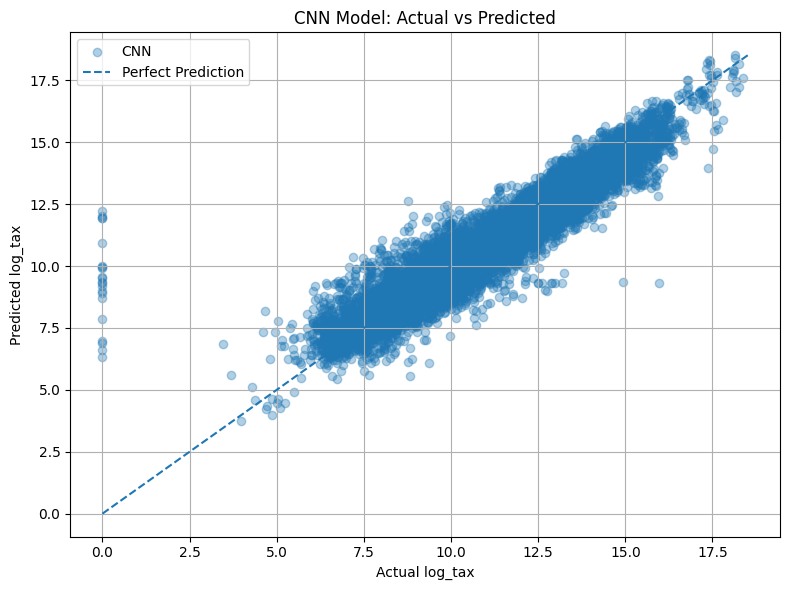

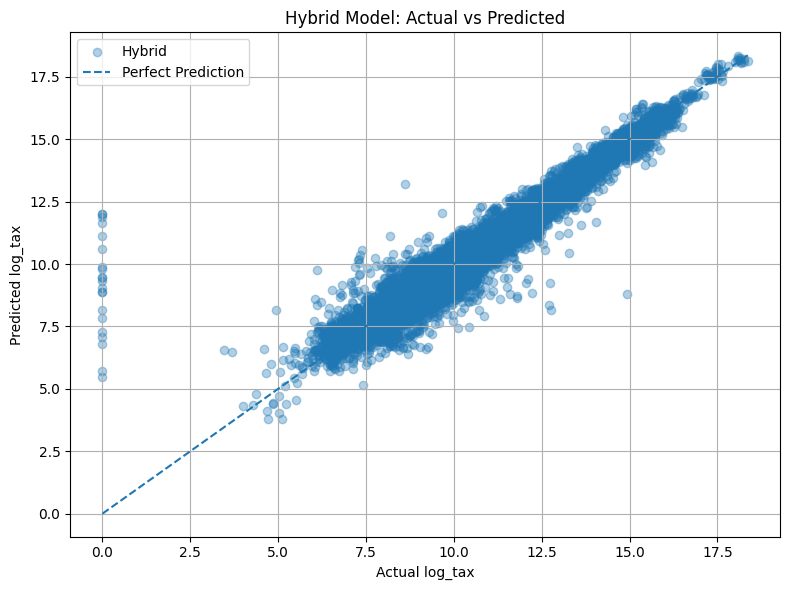

In [ ]:
# ==========================================================
# CELL 24B: RECOVER SAVED IMAGE ARRAYS AND METADATA
# ==========================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test_img, y_pred_test_cnn, alpha=0.35, label="CNN")

min_val = min(y_test_img.min(), y_pred_test_cnn.min())
max_val = max(y_test_img.max(), y_pred_test_cnn.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual log_tax")
plt.ylabel("Predicted log_tax")
plt.title("CNN Model: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{base}/cnn_actual_vs_predicted_line.png", dpi=300, bbox_inches="tight")
plt.show()

#Hybrid
plt.figure(figsize=(8, 6))
plt.scatter(y_test_img, y_pred_test_h, alpha=0.35, label="Hybrid")

min_val = min(y_test_img.min(), y_pred_test_h.min())
max_val = max(y_test_img.max(), y_pred_test_h.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", label="Perfect Prediction")

plt.xlabel("Actual log_tax")
plt.ylabel("Predicted log_tax")
plt.title("Hybrid Model: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{base}/hybrid_actual_vs_predicted_line.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ==========================================================
# CELL 24C: HYBRID PERFORMANCE BY POPULATION GROUP
# ==========================================================

hybrid_test_group_df = test_meta.copy()
hybrid_test_group_df["y_true"] = y_test_img
hybrid_test_group_df["y_pred_hybrid"] = y_pred_test_h

hybrid_test_group_df = hybrid_test_group_df.merge(
    avg_population_per_city[["City_std", "avg_population", "population_group"]],
    on="City_std",
    how="left"
)

hybrid_test_group_df = hybrid_test_group_df.dropna(subset=["population_group"]).reset_index(drop=True)

hybrid_group_results = []

for group_name in sorted(hybrid_test_group_df["population_group"].dropna().unique()):

    test_g = hybrid_test_group_df[
        hybrid_test_group_df["population_group"] == group_name
    ].copy()

    eval_g = evaluate_regression(
        test_g["y_true"].values,
        test_g["y_pred_hybrid"].values,
        f"Hybrid on {group_name}"
    )

    eval_g["population_group"] = group_name
    eval_g["cities"] = test_g["City_std"].nunique()
    eval_g["avg_population_min"] = test_g["avg_population"].min()
    eval_g["avg_population_max"] = test_g["avg_population"].max()

    hybrid_group_results.append(eval_g)

hybrid_results_by_population = pd.DataFrame(hybrid_group_results)

# Add full image-sample test result
hybrid_full_row = hybrid_test_eval.copy()
hybrid_full_row["population_group"] = "Full image-sample"
hybrid_full_row["cities"] = hybrid_test_group_df["City_std"].nunique()
hybrid_full_row["avg_population_min"] = hybrid_test_group_df["avg_population"].min()
hybrid_full_row["avg_population_max"] = hybrid_test_group_df["avg_population"].max()

hybrid_results_by_population = pd.concat(
    [pd.DataFrame([hybrid_full_row]), hybrid_results_by_population],
    ignore_index=True
)

display(hybrid_results_by_population)

hybrid_results_by_population.to_csv(
    f"{base}/hybrid_performance_by_population_group.csv",
    index=False
)

print(f"Saved: {base}/hybrid_performance_by_population_group.csv")

,model,RMSE,R2,population_group,cities,avg_population_min,avg_population_max
0,Hybrid CNN + Radiance (Test),0.619510,0.924947,Full image-sample,1136,3.75,2328354.5
1,Hybrid on PopGroup_1,0.925949,0.491031,PopGroup_1,227,3.75,555.0
2,Hybrid on PopGroup_2,0.611771,0.598401,PopGroup_2,226,556.30,1401.3
3,Hybrid on PopGroup_3,0.445691,0.765502,PopGroup_3,228,1405.70,3150.6
4,Hybrid on PopGroup_4,0.620318,0.638883,PopGroup_4,227,3153.70,10559.0
5,Hybrid on PopGroup_5,0.324730,0.922365,PopGroup_5,228,10570.30,2328354.5


Saved: /content/drive/MyDrive/CSCE nightlights_project/hybrid_performance_by_population_group.csv


In [ ]:
# ==========================================================
# CELL 24D: COMBINE OVERALL AND POPULATION-GROUP R2 RESULTS
# FROM LR, MLP, CNN, AND HYBRID
# ==========================================================

import pandas as pd
import os
import re

# Load all four result tables
lr = pd.read_csv(f"{base}/pooled_lr_performance_by_group.csv")
mlp = pd.read_csv(f"{base}/mlp_performance_by_population_group.csv")
cnn = pd.read_csv(f"{base}/cnn_performance_by_population_group.csv")
hybrid = pd.read_csv(f"{base}/hybrid_performance_by_population_group.csv")

# ----------------------------------------------------------
# Helper: create population_group if missing
# ----------------------------------------------------------
def standardize_group_column(df):
    df = df.copy()

    if "population_group" not in df.columns:
        df["population_group"] = df["model"].astype(str).str.extract(r"(PopGroup_\d+)")

    df["population_group"] = df["population_group"].astype(str)

    return df

lr = standardize_group_column(lr)
mlp = standardize_group_column(mlp)
cnn = standardize_group_column(cnn)
hybrid = standardize_group_column(hybrid)

# ----------------------------------------------------------
# Helper: extract overall R2
# ----------------------------------------------------------
def get_overall_r2(df):
    overall_rows = df[
        ~df["population_group"].str.contains("PopGroup", case=False, na=False)
    ].copy()

    if len(overall_rows) > 0:
        return overall_rows.iloc[0]["R2"]
    else:
        return None

overall_row = pd.DataFrame([{
    "Population Group": "Overall",
    "Number of Cities": lr["cities"].max() if "cities" in lr.columns else None,
    "Linear Regression R2": get_overall_r2(lr),
    "MLP R2": get_overall_r2(mlp),
    "CNN R2": get_overall_r2(cnn),
    "Hybrid R2": get_overall_r2(hybrid),
    "Population Min": None,
    "Population Max": None
}])

# ----------------------------------------------------------
# Keep only PopGroup rows
# ----------------------------------------------------------
lr_groups = lr[lr["population_group"].str.contains("PopGroup", case=False, na=False)].copy()
mlp_groups = mlp[mlp["population_group"].str.contains("PopGroup", case=False, na=False)].copy()
cnn_groups = cnn[cnn["population_group"].str.contains("PopGroup", case=False, na=False)].copy()
hybrid_groups = hybrid[hybrid["population_group"].str.contains("PopGroup", case=False, na=False)].copy()

# ----------------------------------------------------------
# Start from LR because it has number of cities and population range
# ----------------------------------------------------------
combined_r2 = lr_groups[[
    "population_group",
    "cities",
    "R2",
    "avg_population_min",
    "avg_population_max"
]].copy()

combined_r2 = combined_r2.rename(columns={
    "cities": "Number of Cities",
    "R2": "Linear Regression R2",
    "avg_population_min": "Population Min",
    "avg_population_max": "Population Max"
})

# Add MLP, CNN, Hybrid R2 values
combined_r2 = combined_r2.merge(
    mlp_groups[["population_group", "R2"]].rename(columns={"R2": "MLP R2"}),
    on="population_group",
    how="left"
)

combined_r2 = combined_r2.merge(
    cnn_groups[["population_group", "R2"]].rename(columns={"R2": "CNN R2"}),
    on="population_group",
    how="left"
)

combined_r2 = combined_r2.merge(
    hybrid_groups[["population_group", "R2"]].rename(columns={"R2": "Hybrid R2"}),
    on="population_group",
    how="left"
)

# Sort groups nicely
combined_r2["group_number"] = combined_r2["population_group"].str.extract(r"(\d+)").astype(int)
combined_r2 = combined_r2.sort_values("group_number")

# Change PopGroup_1 to Group 1, etc.
combined_r2["Population Group"] = combined_r2["group_number"].apply(lambda x: f"Group {x}")

combined_r2 = combined_r2.drop(columns=["population_group", "group_number"])

# Reorder columns: population min/max at the end
combined_r2 = combined_r2[[
    "Population Group",
    "Number of Cities",
    "Linear Regression R2",
    "MLP R2",
    "CNN R2",
    "Hybrid R2",
    "Population Min",
    "Population Max"
]]

# Add overall row at the top
combined_r2 = pd.concat([overall_row, combined_r2], ignore_index=True)

# Round for nicer reporting
round_cols = [
    "Linear Regression R2", "MLP R2", "CNN R2", "Hybrid R2",
    "Population Min", "Population Max"
]

combined_r2[round_cols] = combined_r2[round_cols].round(3)

display(combined_r2)

combined_r2.to_csv(
    f"{base}/combined_r2_all_models.csv",
    index=False
)

print(f"Saved: {base}/combined_r2_overall_and_population_group_all_models.csv")

/tmp/ipykernel_1008/3636640179.py:125: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_r2 = pd.concat([overall_row, combined_r2], ignore_index=True)


,Population Group,Number of Cities,Linear Regression R2,MLP R2,CNN R2,Hybrid R2,Population Min,Population Max
0,Overall,1146,0.809,0.835,0.869,0.925,NaN,NaN
1,Group 1,228,0.178,0.171,0.367,0.491,3.75,555.0
2,Group 2,227,0.052,0.083,0.423,0.598,556.30,1401.3
3,Group 3,228,0.132,0.273,0.539,0.766,1405.70,3150.6
4,Group 4,228,0.085,0.196,0.333,0.639,3153.70,10559.0
5,Group 5,228,0.372,0.673,0.524,0.922,10570.30,2328354.5


Saved: /content/drive/MyDrive/CSCE nightlights_project/combined_r2_overall_and_population_group_all_models.csv


In [ ]:
# ==========================================================
# CELL 25: FINAL RESULTS TABLE
# Uses saved radiance results from Drive
# ==========================================================
lr_row = results_rad[results_rad["model"] == "Linear Regression (Test)"].iloc[0]
mlp_row = results_rad[results_rad["model"] == "MLP (Test)"].iloc[0]

results = []

results.append({
    "Model": "Linear Regression",
    "Input": "Radiance",
    "Split": "Test",
    "RMSE": lr_row["RMSE"],
  #  "MAE": lr_row["MAE"],
    "R2": lr_row["R2"],
})

results.append({
    "Model": "MLP",
    "Input": "Radiance",
    "Split": "Test",
    "RMSE": mlp_row["RMSE"],
#    "MAE": mlp_row["MAE"],
    "R2": mlp_row["R2"],
})

results.append({
    "Model": "CNN",
    "Input": "Image",
    "Split": "Test",
    "RMSE": cnn_test_eval["RMSE"],
 #   "MAE": cnn_test_eval["MAE"],
    "R2": cnn_test_eval["R2"],
})

results.append({
    "Model": "Hybrid",
    "Input": "Image + Radiance",
    "Split": "Test",
    "RMSE": hybrid_test_eval["RMSE"],
 #   "MAE": hybrid_test_eval["MAE"],
    "R2": hybrid_test_eval["R2"],
})

results_df = pd.DataFrame(results)
results_df

results_df.to_csv(f"{base}/final_model_comparison.csv", index=False)
print(f"Saved: {base}/final_model_comparison.csv")

Saved: /content/drive/MyDrive/CSCE nightlights_project/final_model_comparison.csv


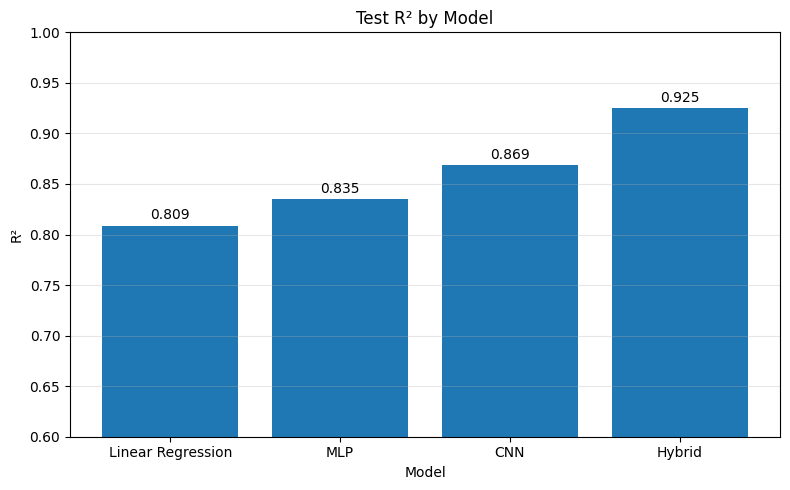

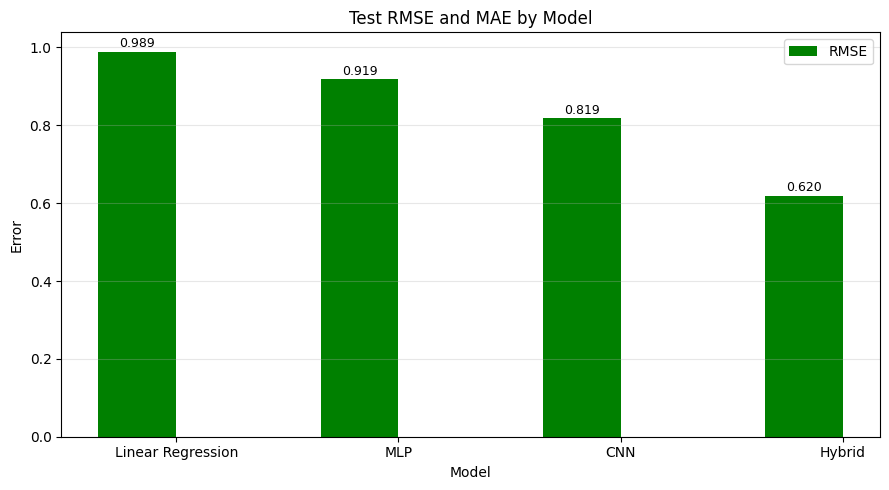

Saved: /content/drive/MyDrive/CSCE nightlights_project/r2_bar_chart.png
Saved: /content/drive/MyDrive/CSCE nightlights_project/rmse_mae_grouped_bar_chart.png


In [ ]:
# ==========================================================
# CELL 26: BAR CHARTS FOR FINAL MODEL COMPARISON
# ==========================================================
import numpy as np
import matplotlib.pyplot as plt

# Keep model order fixed
plot_df = results_df.copy()
model_order = ["Linear Regression", "MLP", "CNN", "Hybrid"]
plot_df["Model"] = pd.Categorical(plot_df["Model"], categories=model_order, ordered=True)
plot_df = plot_df.sort_values("Model")

# ------------------------------
# 1) R2 bar chart
# ------------------------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df["Model"], plot_df["R2"])
plt.ylim(0.60, max(1.0, plot_df["R2"].max() + 0.02))
plt.ylabel("R²")
plt.xlabel("Model")
plt.title("Test R² by Model")
plt.grid(axis="y", alpha=0.3)

# Optional value labels
for i, v in enumerate(plot_df["R2"]):
    plt.text(i, v + 0.003, f"{v:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(f"{base}/r2_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------
# 2) Grouped bar chart for RMSE and MAE
# ------------------------------
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["RMSE"], width, label="RMSE", color="green")
#plt.bar(x + width/2, plot_df["MAE"],  width, label="MAE",  color="darkorange")
#plt.ylim(0.30, max(1.0, plot_df["MAE"].max() + 0.02))

plt.xticks(x, plot_df["Model"])
plt.ylabel("Error")
plt.xlabel("Model")
plt.title("Test RMSE and MAE by Model")
plt.legend()
plt.grid(axis="y", alpha=0.3)

# Optional value labels
for i, v in enumerate(plot_df["RMSE"]):
    plt.text(i - width/2, v + 0.003, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

#for i, v in enumerate(plot_df["MAE"]):
 #   plt.text(i + width/2, v + 0.003, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(f"{base}/rmse_mae_grouped_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {base}/r2_bar_chart.png")
print(f"Saved: {base}/rmse_mae_grouped_bar_chart.png")

# SAMPLES

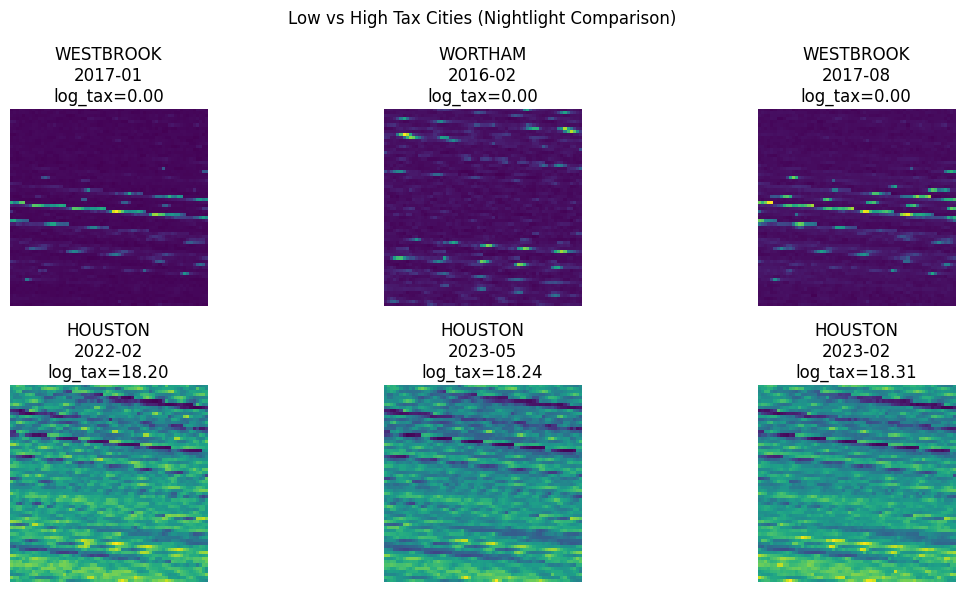

In [ ]:
# ==========================================================
# CELL 27:
# ==========================================================
# sort by tax
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# Check if y_train_img is defined, if not, try to load necessary components
if 'y_train_img' not in locals() and 'y_train_img' not in globals():
    print("y_train_img, X_train_img, or train_meta not found. Attempting to load required data...")
    base = "/content/drive/MyDrive/CSCE nightlights_project"
    train_meta = pd.read_csv(f"{base}/train_meta.csv")
    y_train_img = train_meta["log_tax"].values
    X_train_img = np.load(f"{base}/X_train_img.npy")

sorted_idx = np.argsort(y_train_img)

low_idx = sorted_idx[:3]
high_idx = sorted_idx[-3:]

indices = list(low_idx) + list(high_idx)

plt.figure(figsize=(12, 6))

for i, j in enumerate(indices):
    plt.subplot(2, 3, i+1)
    plt.imshow(X_train_img[j].squeeze(), cmap='viridis')

    city = train_meta.iloc[j]["City_std"]
    month = str(train_meta.iloc[j]["month"])[:7]
    tax = y_train_img[j]

    plt.title(f"{city}\n{month}\nlog_tax={tax:.2f}")
    plt.axis('off')

plt.suptitle("Low vs High Tax Cities (Nightlight Comparison)")
plt.tight_layout()
plt.savefig("nightlights_low_high_tax.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ==========================================================
# CELL 27 NEW: Compare 3 Low-Population and 3 High-Population Cities
#          for the Same Month
# ==========================================================

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Load data if needed
# ----------------------------------------------------------
base = "/content/drive/MyDrive/CSCE nightlights_project"

if 'train_meta' not in globals():
    train_meta = pd.read_csv(f"{base}/train_meta.csv")

if 'X_train_img' not in globals():
    X_train_img = np.load(f"{base}/X_train_img.npy")

if 'y_train_img' not in globals():
    y_train_img = train_meta["log_tax"].values

# ----------------------------------------------------------
# Make sure month is properly formatted
# ----------------------------------------------------------
train_meta["month"] = pd.to_datetime(train_meta["month"])
train_meta["month_ym"] = train_meta["month"].dt.to_period("M").astype(str)

# ----------------------------------------------------------
# Choose one month
# You can change this month manually
# ----------------------------------------------------------
selected_month = "2023-02"

month_df = train_meta[train_meta["month_ym"] == selected_month].copy()

# Keep observations with valid population and image index
month_df = month_df.dropna(subset=["population", "log_tax"])

# ----------------------------------------------------------
# Pick 3 lowest-population and 3 highest-population cities
# ----------------------------------------------------------
low_pop = month_df.sort_values("population").head(3)
high_pop = month_df.sort_values("population").tail(3)

selected_df = pd.concat([low_pop, high_pop])

indices = selected_df.index.tolist()

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
plt.figure(figsize=(12, 6))

for i, j in enumerate(indices):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train_img[j].squeeze(), cmap="viridis")

    city = train_meta.loc[j, "City_std"]
    month = train_meta.loc[j, "month_ym"]
    pop = train_meta.loc[j, "population"]
    tax = train_meta.loc[j, "log_tax"]

    plt.title(
        f"{city}\n{month}\nPop={pop:,.0f}\nlog_tax={tax:.2f}",
        fontsize=10
    )
    plt.axis("off")

plt.suptitle(
    f"Low- vs High-Population Cities: Nighttime Light Comparison ({selected_month})",
    fontsize=14
)

plt.tight_layout()
plt.savefig("nightlights_low_high_population_same_month.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ==========================================================
# Graphical Abstract: Low- vs High-Population Cities
# ==========================================================

selected_month = "2023-12"

month_df = train_meta[train_meta["month_ym"] == selected_month].copy()
month_df = month_df.dropna(subset=["population", "log_tax"])

low_pop = month_df.sort_values("population").head(3)
high_pop = month_df.sort_values("population").tail(3)

selected_df = pd.concat([low_pop, high_pop])
indices = selected_df.index.tolist()

plt.figure(figsize=(13, 7))

for i, j in enumerate(indices):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train_img[j].squeeze(), cmap="viridis")

    city = train_meta.loc[j, "City_std"]
    pop = train_meta.loc[j, "population"]

    plt.title(
        f"{city}\nPopulation={pop:,.0f}",
        fontsize=11
    )
    plt.axis("off")

plt.suptitle(
    "Nighttime-Light Patterns Across Texas Cities",
    fontsize=18,
    y=0.98
)

plt.figtext(
    0.5, 0.02,
    "Nighttime-light signals become more structured and informative in larger urban environments.",
    ha="center",
    fontsize=12
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig("graphical_abstract_nightlights.png", dpi=300, bbox_inches="tight")
plt.show()